#  Detector de Deepfakes 

> Pipeline completo: validación, **balanceo**, entrenamiento e inferencia con **YOLOv8 Classification**.

---

| Paso | Sección |
|:---:|---|
| 1 | ⚙️ Preparación del entorno |
| 2 | 🎛️ Configuración de parámetros |
| 3 | 📊 Validación del dataset |
| 4 | ⚖️ Balanceo del dataset (undersampling reversible) |
| 5 | 🏋️ Entrenamiento del modelo |
| 6 | 🎯 Selección del modelo entrenado |
| 7 | 🔍 **Predicción interactiva** — pega cualquier URL y obtén el veredicto |

---

##  1. Preparación del entorno

Detecta la raíz del proyecto, agrega `src/` al path y carga las utilidades compartidas.

In [26]:
from __future__ import annotations

import csv
import random
import shutil
import sys
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import requests
from matplotlib.gridspec import GridSpec
from PIL import Image


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto.')


PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from detector_deepfake.config import ensure_yolo_dataset_layout, get_runs_dir
from detector_deepfake.inference import classify_image, resolve_model_path
from ultralytics import YOLO

plt.style.use('seaborn-v0_8-darkgrid')
print(f'✅ Proyecto cargado: {PROJECT_ROOT}')

✅ Proyecto cargado: D:\proyectos\Detector de ia


##  2. Configuración

Ajusta los parámetros antes de ejecutar. Esta versión arranca con **defaults compatibles con el cuaderno 02**, que fue el que te daba mejores resultados.

| Parámetro | Descripción |
|---|---|
| `EPOCHS` | Épocas de entrenamiento |
| `BATCH` | Tamaño del batch |
| `FRACTION` | Fracción del dataset (1.0 = completo) |
| `CONFIRM_TRAINING` | Lanzar entrenamiento (`True` / `False`) |
| `BALANCE_DATASET` | Balancear clases antes de entrenar |
| `USE_LATEST_MODEL` | Usar el `best.pt` más reciente para inferencia |
| `LEGACY_REFERENCE_MODEL` | Modelo de referencia estable tomado de corridas previas |

In [33]:
# ── Dataset y rutas ──────────────────────────────────────────
RAW_PROJECT_DATASET_DIR = PROJECT_ROOT / 'dataset_deepdetect' / 'ddata'
PROJECT_DATASET_DIR = RAW_PROJECT_DATASET_DIR.resolve()
DATASET_DIR = ensure_yolo_dataset_layout(PROJECT_DATASET_DIR)
RUNS_DIR = get_runs_dir()
DOWNLOAD_DIR = PROJECT_ROOT / 'results' / 'generated' / 'downloads'
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f'No existe el dataset del proyecto: {DATASET_DIR}')

DATASET_IS_REDIRECTED = RAW_PROJECT_DATASET_DIR.resolve() != RAW_PROJECT_DATASET_DIR

# ── Modo compatible con el cuaderno 02 ───────────────────────
LEGACY_REFERENCE_MODEL = RUNS_DIR / 'deepfake_det_50606' / 'weights' / 'best.pt'
LEGACY_COMPAT_MODE = True

# ── Modelo base ──────────────────────────────────────────────
BASE_MODEL = 'yolov8n-cls.pt'
EXPERIMENT_NAME = 'final_legacy_compatible'

# ── Hiperparámetros ─────────────────────────────────────────
EPOCHS = 5
BATCH = 64
IMGSZ = 224
WORKERS = 0
DEVICE = '0'
FRACTION = 1.0
SAVE_PERIOD = -1
CACHE_IMAGES = False

# ── Flags de control ────────────────────────────────────────
CONFIRM_TRAINING = False
BALANCE_DATASET = False
USE_LATEST_MODEL = False
MODEL_PATH = LEGACY_REFERENCE_MODEL if LEGACY_REFERENCE_MODEL.exists() else None

# ── Resumen ─────────────────────────────────────────────────
params = {
    'RAW_PROJECT_DATASET_DIR': RAW_PROJECT_DATASET_DIR,
    'PROJECT_DATASET_DIR': PROJECT_DATASET_DIR,
    'DATASET_DIR': DATASET_DIR,
    'RUNS_DIR': RUNS_DIR,
    'LEGACY_REFERENCE_MODEL': LEGACY_REFERENCE_MODEL,
    'LEGACY_COMPAT_MODE': LEGACY_COMPAT_MODE,
    'BASE_MODEL': BASE_MODEL,
    'EXPERIMENT_NAME': EXPERIMENT_NAME,
    'EPOCHS': EPOCHS,
    'BATCH': BATCH,
    'IMGSZ': IMGSZ,
    'DEVICE': DEVICE,
    'FRACTION': FRACTION,
    'SAVE_PERIOD': SAVE_PERIOD,
    'CONFIRM_TRAINING': CONFIRM_TRAINING,
    'BALANCE_DATASET': BALANCE_DATASET,
    'USE_LATEST_MODEL': USE_LATEST_MODEL,
}
print('🎛️ Configuración activa:')
for k, v in params.items():
    print(f'   {k:24s} = {v}')

if LEGACY_COMPAT_MODE:
    print('\n✅ Modo compatible con el cuaderno 02 activado.')
    print('   Defaults: batch=64, fraction=1.0, balanceo desactivado y modelo estable por defecto.')

if DATASET_IS_REDIRECTED:
    print('\n⚠️ ADVERTENCIA: la carpeta dataset_deepdetect del proyecto redirige a otra ruta.')
    print(f'   Ruta visible:  {RAW_PROJECT_DATASET_DIR}')
    print(f'   Ruta real:     {PROJECT_DATASET_DIR}')
    print('   El entrenamiento e inferencia usarán la ruta real mostrada arriba.')

if PROJECT_ROOT not in DATASET_DIR.parents and DATASET_DIR != RAW_PROJECT_DATASET_DIR:
    print('\n⚠️ DATASET_DIR queda fuera del árbol del proyecto visible.')
    print('   Esto suele indicar un junction, symlink o almacenamiento cacheado externo.')

🎛️ Configuración activa:
   RAW_PROJECT_DATASET_DIR  = D:\proyectos\Detector de ia\dataset_deepdetect\ddata
   PROJECT_DATASET_DIR      = C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata
   DATASET_DIR              = C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata
   RUNS_DIR                 = D:\proyectos\Detector de ia\runs\classify\runs_yolo
   LEGACY_REFERENCE_MODEL   = D:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt
   LEGACY_COMPAT_MODE       = True
   BASE_MODEL               = yolov8n-cls.pt
   EXPERIMENT_NAME          = final_legacy_compatible
   EPOCHS                   = 5
   BATCH                    = 64
   IMGSZ                    = 224
   DEVICE                   = 0
   FRACTION                 = 1.0
   SAVE_PERIOD              = -1
   CONFIRM_TRAINING         = False
   BALANCE_DATASET          = False
   USE_LATEST_MODEL         = False

✅ Modo compati

## 📊 3. Validación del dataset

Resumen de imágenes por split y clase con visualización.

Split        fake     real    Total  Ratio f/r
──────────────────────────────────────────────
train      41,592   41,592   83,184       1.00
val        10,399   11,377   21,776       0.91
test       10,399   11,377   21,776       0.91


C:\Users\marce\AppData\Local\Temp\ipykernel_36036\2670545368.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
d:\proyectos\Detector de ia\.venv312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


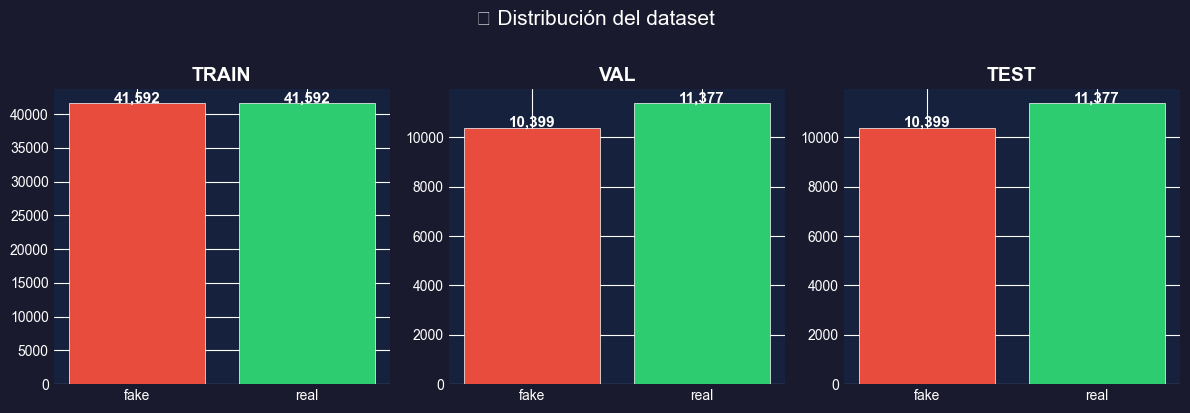

In [15]:
def count_images(split_dir: Path) -> dict[str, int]:
    counts: dict[str, int] = {}
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        counts[class_dir.name] = sum(1 for p in class_dir.rglob('*') if p.is_file())
    return counts


dataset_summary: dict[str, dict[str, int]] = {}
for split in ['train', 'val', 'test']:
    split_dir = DATASET_DIR / split
    if split_dir.exists():
        dataset_summary[split] = count_images(split_dir)

# ── Tabla resumen ──
print(f'{"Split":<8} {"fake":>8} {"real":>8} {"Total":>8} {"Ratio f/r":>10}')
print('─' * 46)
for split, counts in dataset_summary.items():
    f, r = counts.get('fake', 0), counts.get('real', 0)
    ratio = f'{f / r:.2f}' if r > 0 else '∞'
    print(f'{split:<8} {f:>8,} {r:>8,} {f + r:>8,} {ratio:>10}')

# ── Gráfico ──
DARK_BG = '#1a1a2e'
PANEL_BG = '#16213e'
CLASS_COLORS = {'fake': '#e74c3c', 'real': '#2ecc71'}

n = len(dataset_summary)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), facecolor=DARK_BG)
if n == 1:
    axes = [axes]
for ax, (split, counts) in zip(axes, dataset_summary.items()):
    ax.set_facecolor(PANEL_BG)
    labels = list(counts.keys())
    values = list(counts.values())
    bars = ax.bar(labels, values,
                  color=[CLASS_COLORS.get(l, '#3498db') for l in labels],
                  edgecolor='white', linewidth=0.5)
    ax.set_title(split.upper(), color='white', fontsize=14, fontweight='bold')
    ax.tick_params(colors='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f'{val:,}', ha='center', color='white', fontsize=11, fontweight='bold')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']:
        ax.spines[sp].set_color('white')
plt.suptitle('📊 Distribución del dataset', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## ⚖️ 4. Balanceo del dataset

Si las clases `fake` y `real` tienen distinta cantidad de imágenes en el split de entrenamiento,
esta celda iguala ambas mediante **undersampling aleatorio**.

> 💡 **Reversible:** las imágenes sobrantes se mueven a `_backup_train/`, no se eliminan.
> Para restaurar el dataset original, ejecuta `restore_backup(DATASET_DIR)` en una celda aparte.

⚠️  Ya existe backup en _backup_train/.
     Estado actual — fake: 41,592, real: 41,592
     Restaura primero con restore_backup() si quieres rebalancear.


C:\Users\marce\AppData\Local\Temp\ipykernel_36036\4240121915.py:81: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\marce\AppData\Local\Temp\ipykernel_36036\4240121915.py:81: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
d:\proyectos\Detector de ia\.venv312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\proyectos\Detector de ia\.venv312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


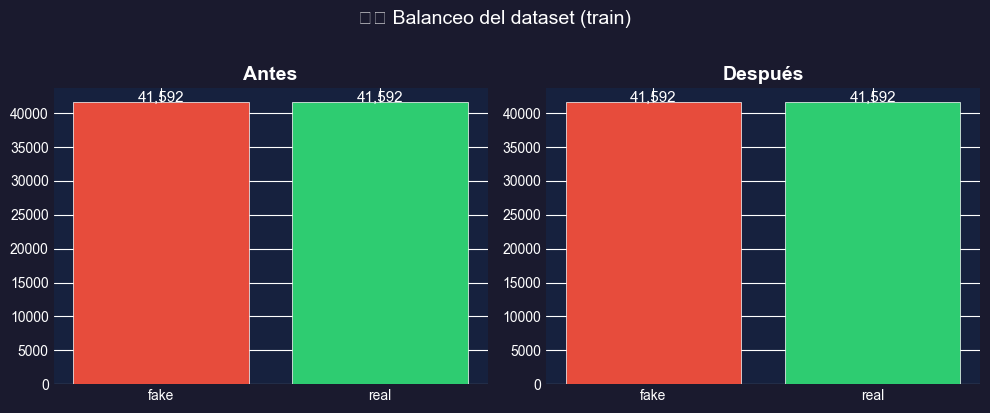

In [16]:
def balance_dataset(dataset_dir: Path, split: str = 'train', seed: int = 42):
    """Balancea clases moviendo imágenes sobrantes a un backup reversible."""
    split_dir = dataset_dir / split
    backup_dir = dataset_dir / f'_backup_{split}'

    if backup_dir.exists():
        cur = count_images(split_dir)
        print(f'⚠️  Ya existe backup en {backup_dir.name}/.')
        print(f'     Estado actual — ' + ', '.join(f'{k}: {v:,}' for k, v in cur.items()))
        print('     Restaura primero con restore_backup() si quieres rebalancear.')
        return cur, cur

    class_files: dict[str, list[Path]] = {}
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        class_files[class_dir.name] = sorted(p for p in class_dir.rglob('*') if p.is_file())

    counts_before = {k: len(v) for k, v in class_files.items()}
    min_count = min(counts_before.values())

    if all(c == min_count for c in counts_before.values()):
        print(f'✅ Dataset ya balanceado ({min_count:,} imágenes por clase).')
        return counts_before, counts_before

    random.seed(seed)
    moved = 0
    for cls, files in class_files.items():
        excess = len(files) - min_count
        if excess > 0:
            to_move = random.sample(files, excess)
            dst = backup_dir / cls
            dst.mkdir(parents=True, exist_ok=True)
            for f in to_move:
                shutil.move(str(f), str(dst / f.name))
            moved += excess
            print(f'   {cls}: {len(files):,} → {min_count:,}  (movidas {excess:,})')

    counts_after = {k: min_count for k in class_files}
    print(f'\n⚖️  Balanceado: {min_count:,} imágenes/clase  ({moved:,} al backup)')
    return counts_before, counts_after


def restore_backup(dataset_dir: Path, split: str = 'train'):
    """Restaura imágenes desde el backup al dataset original."""
    backup_dir = dataset_dir / f'_backup_{split}'
    if not backup_dir.exists():
        print('ℹ️  No hay backup para restaurar.')
        return
    split_dir = dataset_dir / split
    restored = 0
    for cls_dir in backup_dir.iterdir():
        if cls_dir.is_dir():
            target = split_dir / cls_dir.name
            for f in cls_dir.iterdir():
                if f.is_file():
                    shutil.move(str(f), str(target / f.name))
                    restored += 1
    shutil.rmtree(backup_dir)
    print(f'✅ {restored:,} imágenes restauradas.')


# ── Ejecutar balanceo ──
if BALANCE_DATASET:
    before, after = balance_dataset(DATASET_DIR)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor=DARK_BG)
    for ax, data, title in [(ax1, before, 'Antes'), (ax2, after, 'Después')]:
        ax.set_facecolor(PANEL_BG)
        bars = ax.bar(data.keys(), data.values(),
                      color=[CLASS_COLORS.get(k, '#3498db') for k in data],
                      edgecolor='white', linewidth=0.5)
        ax.set_title(title, color='white', fontsize=14, fontweight='bold')
        ax.tick_params(colors='white')
        for bar, val in zip(bars, data.values()):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                    f'{val:,}', ha='center', color='white', fontsize=11)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        for sp in ['bottom', 'left']:
            ax.spines[sp].set_color('white')
    plt.suptitle('⚖️ Balanceo del dataset (train)', color='white', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('⏸️  Balanceo desactivado. Cambia BALANCE_DATASET = True para activarlo.')

## 🏋️ 5. Entrenamiento

Lanza el entrenamiento de YOLOv8 Classification con los parámetros configurados.

- Solo se ejecuta si `CONFIRM_TRAINING = True`.
- Si la salida aparece truncada, es un límite visual de Jupyter, no un error.

In [17]:
if not CONFIRM_TRAINING:
    print('⏸️  Entrenamiento desactivado.')
    print('   Cambia CONFIRM_TRAINING = True en la celda de configuración.')
else:
    eff = FRACTION if 0 < FRACTION <= 1 else 1.0
    est = int(90407 * eff)
    print(f'🏋️ Iniciando entrenamiento...')
    print(f'   Fracción: {eff}  (~{est:,} imágenes/época)')
    print(f'   Épocas: {EPOCHS}  |  Batch: {BATCH}  |  Device: {DEVICE}')
    print()

    model = YOLO(BASE_MODEL)
    train_results = model.train(
        data=str(DATASET_DIR),
        epochs=EPOCHS,
        batch=BATCH,
        workers=WORKERS,
        cache=CACHE_IMAGES,
        imgsz=IMGSZ,
        project=str(RUNS_DIR),
        name=EXPERIMENT_NAME,
        device=DEVICE,
        fraction=FRACTION,
        save_period=SAVE_PERIOD,
        exist_ok=True,
    )
    MODEL_PATH = Path(train_results.save_dir) / 'weights' / 'best.pt'
    print(f'\n✅ Modelo guardado: {MODEL_PATH}')

🏋️ Iniciando entrenamiento...
   Fracción: 0.2  (~18,081 imágenes/época)
   Épocas: 5  |  Batch: 16  |  Device: 0

New https://pypi.org/project/ultralytics/8.4.27 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.10 torch-2.12.0.dev20260228+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.2, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=Fal

##  6. Selección del modelo

- Si `USE_LATEST_MODEL = True`, se toma el `best.pt` más reciente de `runs/classify/runs_yolo/`.
- Si `USE_LATEST_MODEL = False`, se usa `MODEL_PATH` (manual o generado por el entrenamiento).

In [34]:
manual_model = MODEL_PATH
if not USE_LATEST_MODEL and manual_model is None and LEGACY_REFERENCE_MODEL.exists():
    manual_model = LEGACY_REFERENCE_MODEL

if USE_LATEST_MODEL:
    selected_model = resolve_model_path(None, runs_dir=RUNS_DIR)
    selection_mode = 'latest'
else:
    if manual_model is None:
        raise FileNotFoundError('USE_LATEST_MODEL = False pero no hay MODEL_PATH ni modelo de referencia disponible.')
    selected_model = resolve_model_path(manual_model, runs_dir=RUNS_DIR)
    selection_mode = 'manual/reference'

size_mb = selected_model.stat().st_size / 1024 / 1024
print(f'🎯 Modelo seleccionado: {selected_model}')
print(f'   Modo de selección: {selection_mode}')
print(f'   Tamaño: {size_mb:.1f} MB')

🎯 Modelo seleccionado: D:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt
   Modo de selección: manual/reference
   Tamaño: 2.8 MB


In [35]:
def inspect_run_health(model_path: Path) -> dict[str, object]:
    run_dir = model_path.parent.parent
    results_csv = run_dir / 'results.csv'
    health = {
        'run_dir': run_dir,
        'results_csv': results_csv,
        'status': 'unknown',
        'warnings': [],
        'last_metrics': {},
    }

    if not results_csv.exists():
        health['status'] = 'missing-results'
        health['warnings'].append('No existe results.csv para esta corrida.')
        return health

    with results_csv.open('r', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))

    if not rows:
        health['status'] = 'empty-results'
        health['warnings'].append('results.csv está vacío.')
        return health

    def as_float(row: dict[str, str], key: str) -> float:
        return float(row[key])

    accuracies = [as_float(row, 'metrics/accuracy_top1') for row in rows]
    val_losses = [as_float(row, 'val/loss') for row in rows]
    train_losses = [as_float(row, 'train/loss') for row in rows]
    last = rows[-1]

    health['last_metrics'] = {
        'accuracy_top1': accuracies[-1],
        'val_loss': val_losses[-1],
        'train_loss': train_losses[-1],
        'epochs': len(rows),
    }

    acc_span = max(accuracies) - min(accuracies)
    if acc_span < 0.01:
        health['warnings'].append('accuracy_top1 quedó prácticamente plana durante toda la corrida.')

    if val_losses[-1] > val_losses[0] and train_losses[-1] <= train_losses[0]:
        health['warnings'].append('val_loss empeoró mientras train/loss cayó: señal típica de sobreajuste o colapso.')

    if accuracies[-1] < 0.6:
        health['warnings'].append('accuracy_top1 final es baja para un clasificador binario.')

    health['status'] = 'warning' if health['warnings'] else 'ok'
    return health


run_health = inspect_run_health(selected_model)
print(f'🩺 Run analizada: {run_health["run_dir"]}')
metrics = run_health['last_metrics']
if metrics:
    print(f"   epochs          = {metrics['epochs']}")
    print(f"   accuracy_top1   = {metrics['accuracy_top1']:.4f}")
    print(f"   train/loss      = {metrics['train_loss']:.6f}")
    print(f"   val/loss        = {metrics['val_loss']:.6f}")

if run_health['warnings']:
    print('\n⚠️ Señales de alerta detectadas:')
    for warning in run_health['warnings']:
        print(f'   - {warning}')
else:
    print('\n✅ No se detectaron señales claras de colapso en esta revisión rápida.')

🩺 Run analizada: D:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606
   epochs          = 5
   accuracy_top1   = 0.6836
   train/loss      = 0.078210
   val/loss        = 1.331130

⚠️ Señales de alerta detectadas:
   - val_loss empeoró mientras train/loss cayó: señal típica de sobreajuste o colapso.


## 6.1 Chequeo de salud del modelo

Esta sección revisa la corrida asociada al modelo seleccionado y marca señales típicas de colapso:
- `accuracy_top1` estancada
- `val_loss` empeorando mientras `train/loss` cae a cero
- posible clasificación hacia una sola clase

##  7. Predicción interactiva

Pega la **URL de cualquier imagen** de internet (o una ruta local) en la celda de abajo
y ejecuta para obtener el veredicto del modelo con una visualización detallada.

La función descarga la imagen, la clasifica y muestra:
- la imagen original
- el veredicto (**REAL** o **FAKE**) con su confianza
- un gráfico de probabilidades por clase

In [30]:
def predict_and_display(image_input: str, model_path: Path, run_health: dict[str, object] | None = None):
    """Clasifica una imagen (URL o ruta local) y muestra resultados."""

    # ── Resolver imagen ──
    if image_input.startswith(('http://', 'https://')):
        parsed = urlparse(image_input)
        filename = Path(parsed.path).name or 'downloaded.jpg'
        target = DOWNLOAD_DIR / filename
        resp = requests.get(image_input, timeout=60)
        resp.raise_for_status()
        target.write_bytes(resp.content)
        img_path = target
        source_label = '🌐 URL'
    else:
        img_path = Path(image_input).expanduser().resolve()
        source_label = '💾 Local'

    if not img_path.exists():
        raise FileNotFoundError(f'No se encontró: {img_path}')

    # ── Clasificar ──
    prediction = classify_image(img_path, model_path=model_path)
    label = prediction['label']
    confidence = prediction['confidence']
    scores = prediction['scores']
    img = Image.open(img_path).convert('RGB')

    # ── Colores y tema ──
    DARK_BG = '#1a1a2e'
    PANEL_BG = '#16213e'
    theme = {
        'fake': ('#e74c3c', 'FAKE'),
        'real': ('#2ecc71', 'REAL'),
    }
    accent, verdict_text = theme.get(label, ('#3498db', label.upper()))
    bar_colors = {'fake': '#e74c3c', 'real': '#2ecc71'}
    warnings = run_health['warnings'] if run_health else []

    # ── Figura ──
    fig = plt.figure(figsize=(14, 6.6), facecolor=DARK_BG)
    gs = GridSpec(3, 2, figure=fig, width_ratios=[1, 1.2],
                  height_ratios=[1, 1, 0.42], hspace=0.35, wspace=0.3)

    # Panel de imagen
    ax_img = fig.add_subplot(gs[:, 0])
    ax_img.imshow(img)
    ax_img.set_title(img_path.name, color='white', fontsize=11, pad=10)
    ax_img.axis('off')
    for spine in ax_img.spines.values():
        spine.set_edgecolor(accent)
        spine.set_linewidth(3)
        spine.set_visible(True)

    # Panel de veredicto
    ax_v = fig.add_subplot(gs[0, 1])
    ax_v.set_facecolor(PANEL_BG)
    ax_v.text(0.5, 0.62, verdict_text, ha='center', va='center',
              fontsize=30, fontweight='bold', color=accent,
              transform=ax_v.transAxes)
    ax_v.text(0.5, 0.2, f'Confianza: {confidence:.1%}', ha='center', va='center',
              fontsize=18, color='white', transform=ax_v.transAxes,
              bbox=dict(boxstyle='round,pad=0.3', facecolor=accent, alpha=0.3))
    ax_v.set_xlim(0, 1)
    ax_v.set_ylim(0, 1)
    ax_v.axis('off')

    # Panel de probabilidades
    ax_b = fig.add_subplot(gs[1, 1])
    ax_b.set_facecolor(PANEL_BG)
    s_labels = [s[0] for s in scores]
    s_values = [s[1] for s in scores]
    s_colors = [bar_colors.get(l, '#3498db') for l in s_labels]
    bars = ax_b.barh(s_labels, s_values, color=s_colors, height=0.45,
                     edgecolor='white', linewidth=0.5)
    ax_b.set_xlim(0, 1.18)
    ax_b.set_xlabel('Probabilidad', color='white', fontsize=11)
    ax_b.tick_params(colors='white', labelsize=13)
    for bar, val in zip(bars, s_values):
        ax_b.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                  f'{val:.1%}', va='center', color='white', fontsize=14, fontweight='bold')
    for sp in ['top', 'right']:
        ax_b.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']:
        ax_b.spines[sp].set_color('white')

    # Panel de confianza del modelo
    ax_warn = fig.add_subplot(gs[2, 1])
    ax_warn.set_facecolor(PANEL_BG)
    ax_warn.axis('off')
    if warnings:
        ax_warn.text(0.02, 0.68, 'Modelo con alertas de calidad', color='#f1c40f',
                     fontsize=14, fontweight='bold', transform=ax_warn.transAxes)
        ax_warn.text(0.02, 0.22, warnings[0], color='white', fontsize=11,
                     transform=ax_warn.transAxes)
    else:
        ax_warn.text(0.02, 0.5, 'Modelo sin alertas automáticas en la revisión rápida.',
                     color='#2ecc71', fontsize=12, fontweight='bold', transform=ax_warn.transAxes)

    plt.tight_layout()
    plt.show()

    # ── Resumen en texto ──
    print(f'\n{"=" * 52}')
    print(f'  Fuente:     {source_label}')
    print(f'  Archivo:    {img_path.name}')
    print(f'  Modelo:     {model_path.name}')
    print(f'  Veredicto:  {label.upper()} ({confidence:.1%})')
    for lbl, sc in scores:
        filled = int(sc * 30)
        bar_str = '#' * filled + '-' * (30 - filled)
        print(f'    {lbl:6s}  {bar_str}  {sc:.1%}')
    if warnings:
        print('\n  ALERTAS DEL MODELO:')
        for warning in warnings:
            print(f'    - {warning}')
    print(f'{"=" * 52}')


print('✅ Función predict_and_display() lista.')

✅ Función predict_and_display() lista.



image 1/1 C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test\fake\fake_041594.jpg: 224x224 fake 1.00, real 0.00, 4.5ms
Speed: 3.1ms preprocess, 4.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


C:\Users\marce\AppData\Local\Temp\ipykernel_36036\1162243981.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


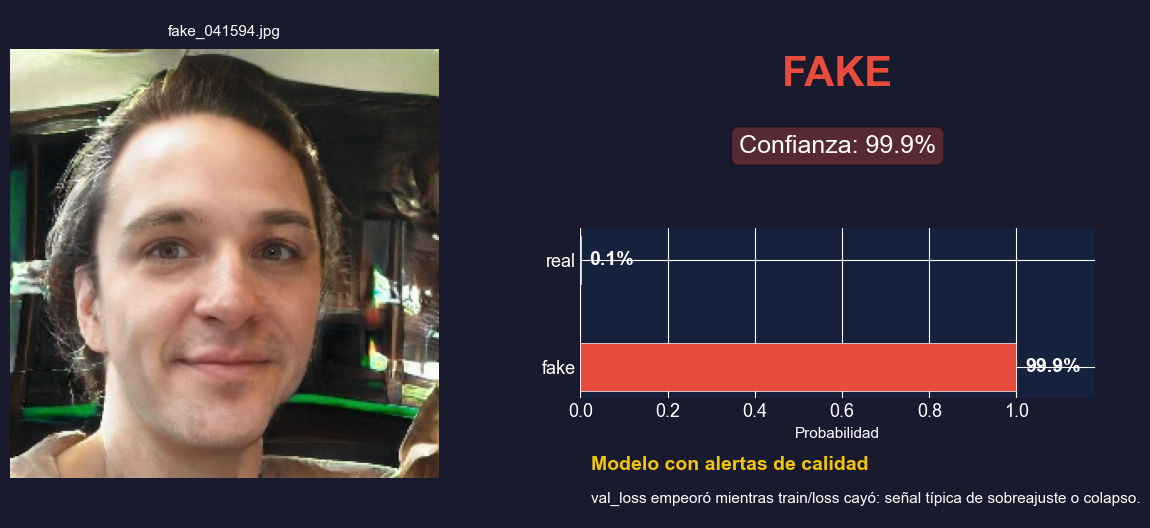


  Fuente:     💾 Local
  Archivo:    fake_041594.jpg
  Modelo:     best.pt
  Veredicto:  FAKE (99.9%)
    fake    #############################-  99.9%
    real    ------------------------------  0.1%

  ALERTAS DEL MODELO:
    - val_loss empeoró mientras train/loss cayó: señal típica de sobreajuste o colapso.


In [36]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PEGA AQUÍ LA URL O RUTA DE LA IMAGEN A ANALIZAR           ║
# ╚══════════════════════════════════════════════════════════════╝

IMAGE_INPUT = str(DATASET_DIR / 'test' / 'fake' / 'fake_041594.jpg')

# Ejemplos de uso:
# IMAGE_INPUT = 'https://dominio.com/imagen.jpg'               # URL de internet
# IMAGE_INPUT = r'C:\ruta\a\mi\imagen.jpg'                   # Ruta local Windows
# IMAGE_INPUT = str(DATASET_DIR / 'test' / 'real' / 'img.jpg') # Imagen del dataset

# ── Ejecutar predicción ──
predict_and_display(IMAGE_INPUT, selected_model, run_health=run_health)

## 📝 8. Recomendaciones de uso

| Escenario | Qué hacer |
|---|---|
| **Entrenamiento real** | Sube `EPOCHS` (≥20), deja `FRACTION = 1.0` y activa `CONFIRM_TRAINING` |
| **Prueba rápida** | Usa `FRACTION = 0.01` y pocas épocas |
| **Comparar modelos** | Cambia `MODEL_PATH` y re-ejecuta las celdas 6 y 7 |
| **Restaurar dataset** | Ejecuta `restore_backup(DATASET_DIR)` en una celda nueva |
| **Cambiar imagen** | Edita `IMAGE_INPUT` en la celda anterior y vuelve a ejecutar |

---

> 🏁 Este es el cuaderno canónico del proyecto. Los cuadernos anteriores pueden archivarse.